# GRB pipeline (heapy + bayspec · 3ML) — time-integrated

Run this notebook **inside Docker** with the **GBM (Python 3.12)** kernel.

Tint-only: load → geometry → heapy tint → **bayspec** tint → **3ML** tint → **GCN comparison**. Time-resolved cells are commented at the bottom.

Current test burst: **GRB150514A** (single FRED, soft Ep). Tint is **GCN 17819** (`T0` to `T0+11.3` s). GBM published **Band**; we fit **CPL** (Konus GCN 17823 CPL is a second check). Spectral fits default to **NaI only**. Also in `GCN_REFS`: `GRB190829A`, `GRB140606B`. Skip **GRB 221009A (BOAT)** — main episode saturates GBM.

| Stage | What |
|-------|------|
| 0 | Config + GCN settings dump (+ optional HDF5 clean checklist) |
| 1–2a | Geometry, heapy tint LC/spectra |
| 3a–4 | bayspec tint → HDF5 key `tint_{model}_{GRB}` |
| 5 | 3ML tint → HDF5 key `tint_{model}_3ML_{GRB}` |
| 6 | **Comparison table** (GCN · bayspec · 3ML, with Δα / ΔEp) |
| 7 | On-disk tree |

Changing the tint window changes the extraction fingerprint. Old C1-window products stay on disk; a new run writes a versioned dir unless you set `FORCE=True` (after the checklist).

```bash
docker exec gbm python -m cli.run_grb GRB150514A --nlive 1000 --force --workers 1
docker exec gbm python -m cli.run_3ml GRB150514A --nlive 1000 --force
```


In [1]:
import copy, importlib, sys, os, json
sys.path.insert(0, '/workspace')

import pipeline.runner as _runner
import pipeline.context as _context
import pipeline.slices as _slices
import pipeline.util as _util
import pipeline.spectra as _spectra
import pipeline.fitting as _fitting
import pipeline.threeml as _threeml
import plot_lightcurves as plc
import grb_config
import grb_utils as gu

for mod in (_runner, _context, _slices, _util, _spectra, _fitting, _threeml,
            plc, grb_config, gu):
    importlib.reload(mod)

from pipeline.runner import GRBPipelineRunner
from pipeline.spectra import active_heapy_tint_dir
from pipeline.util import list_grb_results, show_directory_tree, view_hdf5
from pipeline.fitting import plot_infer_fit, extract_params
from pipeline.threeml import (
    _bkg_intervals, extract_params_3ml, run_3ml, threeml_available,
)
from pipeline.detectors import detector_energy_range, fit_detectors
from pipeline.constants import LOG_EP_PRIOR
from plot_lightcurves import plot_lightcurves
from grb_config import grbs_df_all, ACTIVE_GRBS, gcn_ref
from grb_utils import DATA_BASE, MODELS
from IPython.display import display, Image, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ok_3ml, ver_3ml = threeml_available()
print(f'DATA_BASE={DATA_BASE}')
print(f'ACTIVE_GRBS={ACTIVE_GRBS}')
print(f'threeML={"OK " + str(ver_3ml) if ok_3ml else "unavailable: " + str(ver_3ml)}')
grbs_df_all[['name', 'sel_dets', 't1', 't2', 'tint_t1', 'tint_t2',
             'slice_mode', 'det_mode']]


16:25:43 INFO      Starting 3ML!                                                                     ]8;id=15354425;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354426;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=15354432;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354433;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=15354439;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354440;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#46\46]8;;\

         WARNING    to disable these messages, turn off start_warning in your config file            ]8;id=15354446;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354447;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#47\47]8;;\

         WARNING   no display variable set. using backend for graphics without display (agg)         ]8;id=15354453;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354454;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#53\53]8;;\

...

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=15354497;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354498;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=15354503;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354504;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=15354509;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=15354510;file:///usr/local/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

DATA_BASE=/workspace/data
ACTIVE_GRBS=['GRB140606B']
threeML=OK 2.5.0


,name,sel_dets,t1,t2,tint_t1,tint_t2,slice_mode,det_mode
0,GRB120326A,"[n0, n1]",-2.51,7.49,-2.51,7.49,manual,one_fits_all
1,GRB131011A,"[b1, n9, na, nb]",-2.99,25.01,-2.99,25.01,manual,one_fits_all
2,GRB140606B,"[b0, n3, n4, n8]",-3.00,12.30,-3.00,12.30,manual,one_fits_all
3,GRB150514A,"[b0, n3, n6, n7]",-0.46,6.05,-0.46,6.05,manual,one_fits_all
4,GRB151027A,"[b0, n0, n1, n3]",-0.50,3.50,-0.50,3.50,manual,one_fits_all
5,GRB170607A,"[b0, n2, n5]",-1.57,7.23,-1.57,7.23,manual,one_fits_all
6,GRB190829A,"[n6, n7, n9]",0.00,4.00,0.00,4.00,manual,one_fits_all
7,GRB210204A,"[b1, n7, n8]",32.83,44.34,32.83,44.34,manual,one_fits_all


## 0 — Config

- `INCLUDE_BGO=False`: NaI-only spectral fit (heapy+BGO previously pinned Ep to the 10 MeV prior).
- `RUN_3ML=True`: sections 5–6.
- `FORCE=False` by default — fingerprints include `utc` and `t1`/`t2`. A GCN-window run writes a versioned dir unless you set `True` (after the checklist) to overwrite canonical products.
- Target HDF5 keys after a clean run: **one** bayspec tint key and **one** 3ML tint key.

### GRB150514A vs GCN 17819 (current)

| Setting | GCN 17819 (GBM Band) | This pipeline |
|---------|----------------------|---------------|
| T0 | GBM **18:35:05.35** | same |
| Tint window | **T0 → T0+11.3 s** | **now the same** (was Yan C1 −0.46…6.05) |
| Model | **Band** α/Ep/β | bayspec/3ML **CPL** (soft Ep, steep β → comparable) |
| Konus check | GCN 17823 CPL α≈−1.44, Ep≈60 | optional second comparison |
| Detectors | typical GCN: NaI + BGO | catalog `b0,n3,n6,n7`; **fits NaI-only** |
| Energy | GBM standard | NaI `[8, 900]`, BGO `[300, 38000]` |
| Posterior | RMFIT-style ±1σ | **equal-weight 16/50/84** |

Single FRED (~10 s) — no second pulse in the post-burst background pad. Table C1 slices stay for later tres.


In [2]:
GRB_NAME = 'GRB150514A'  # or GRB190829A / GRB140606B
MODEL = 'cpl'
N_WORKERS = 1            # heapy pool is flaky; sequential is safer
NLIVE = 1000             # production (200 = smoke test)
FORCE = True             # overwrite Yan-C1 tint products for GCN window
INCLUDE_BGO = False
RUN_3ML = True

GCN_REF = gcn_ref(GRB_NAME)
if GCN_REF is None:
    raise KeyError(f'No GCN_REFS entry for {GRB_NAME}')

runner = GRBPipelineRunner(
    n_workers=N_WORKERS, model_name=MODEL, nlive=NLIVE,
    force=FORCE, include_bgo=INCLUDE_BGO)
ctx = runner.load(GRB_NAME)

fit_dets = fit_detectors(ctx.sel_dets, include_bgo=INCLUDE_BGO)
c1 = list(ctx.slice_boundaries) if ctx.slice_boundaries else []
settings = {
    'name': ctx.name,
    'model': MODEL,
    'nlive': NLIVE,
    'force': FORCE,
    'include_bgo': INCLUDE_BGO,
    'tint': [ctx.t1, ctx.t2],
    'gcn_interval': [GCN_REF['t1'], GCN_REF['t2']],
    'table_c1_span': [c1[0], c1[-1]] if c1 else None,
    'catalog_dets': list(ctx.sel_dets or []),
    'fit_dets': list(fit_dets),
    'nai_energy': list(ctx.nai_energy),
    'bgo_energy': list(ctx.bgo_energy),
    'energy_by_det': {d: detector_energy_range(d, ctx=ctx) for d in fit_dets},
    'bs_ignore@0': ctx.bs_ignore_interval(0.0),
    'lc_window@0': ctx.lc_window(0.0),
    'bkg_3ml': _bkg_intervals(ctx),
    'log_Ep_prior': list(LOG_EP_PRIOR),
    'ra': ctx.ra,
    'dec': ctx.dec,
    'gcn_source': GCN_REF['source'],
}
print(json.dumps(settings, indent=2))
print(f'data  {ctx.paths.base}')


  one_fits_all detectors: ['n6', 'n7', 'n9']
Loaded: GRB190829A | 6 slices | tint=(0.0,4.0) | dets=['n6', 'n7', 'n9'] | ext_fp=9a900884
{
  "name": "GRB190829A",
  "model": "cpl",
  "nlive": 1000,
  "force": true,
  "include_bgo": false,
  "tint": [
    0.0,
    4.0
  ],
  "gcn_interval": [
    0.0,
    4.0
  ],
  "table_c1_span": [
    -0.81,
    5.07
  ],
  "catalog_dets": [
    "n6",
    "n7",
    "n9"
  ],
  "fit_dets": [
    "n6",
    "n7",
    "n9"
  ],
  "nai_energy": [
    8.0,
    900.0
  ],
  "bgo_energy": [
    300.0,
    38000.0
  ],
  "energy_by_det": {
    "n6": [
      8.0,
      900.0
    ],
    "n7": [
      8.0,
      900.0
    ],
    "n9": [
      8.0,
      900.0
    ]
  },
  "bs_ignore@0": [
    -0.81,
    5.07
  ],
  "lc_window@0": [
    -20.0,
    55.07
  ],
  "bkg_3ml": [
    "-20.000--0.810",
    "5.070-55.070"
  ],
  "log_Ep_prior": [
    0.0,
    4.0
  ],
  "ra": 44.54402,
  "dec": -8.95837,
  "gcn_source": "GCN 25575"
}
data  /workspace/data/GRB190829A


### Optional — clean old HDF5 / fits (you run this)

Delete stale products **yourself** so HDF5 keeps only the fresh tint keys:

| Path | Why |
|------|-----|
| `{GRB}/data/tresolved/bayspec/{GRB}_bayspec_data.h5` | old keys (`tint_cpl_*`, tres `cpl`/`band`, leaked `*_3ML*`) |
| `{GRB}/data/tresolved/3ML/{GRB}_3ML_data.h5` | old `tint_*_3ML*` keys |
| `{GRB}/data/tintegrated/bayspec/{model}/versions/` | stale fingerprinted fits |
| `{GRB}/data/tintegrated/3ML/{model}/versions/` | stale 3ML fits |

Then set `FORCE=True` above and re-run fit + extract cells.


In [3]:
# Checklist only — does NOT delete. Set CLEAN_NOW=True to remove listed files.
CLEAN_NOW = False

h5_bay = ctx.paths.bayspec_data
h5_3ml = os.path.join(ctx.paths.tresolved_path, '3ML', f'{ctx.name}_3ML_data.h5')
bay_vers = os.path.join(ctx.paths.bayspec_tintegrated_path, MODEL, 'versions')
ml_vers = os.path.join(ctx.paths.tintegrated_path, '3ML', MODEL, 'versions')
targets = [h5_bay, h5_3ml, bay_vers, ml_vers]

print('Current HDF5 keys (if files exist):')
for h5 in (h5_bay, h5_3ml):
    if not os.path.isfile(h5):
        print(f'  (missing) {h5}')
        continue
    import h5py
    with h5py.File(h5, 'r') as f:
        print(f'  {h5}')
        for k in sorted(f.keys()):
            print(f'    · {k}')

print('\nClean targets:')
for p in targets:
    print(f'  {"DIR " if os.path.isdir(p) else "FILE"}  exists={os.path.exists(p)}  {p}')

if CLEAN_NOW:
    import shutil
    for p in targets:
        if os.path.isfile(p):
            os.remove(p); print('removed file', p)
        elif os.path.isdir(p):
            shutil.rmtree(p); print('removed dir ', p)
    print('Done. Set FORCE=True and re-run fits.')
else:
    print('\nCLEAN_NOW=False — nothing deleted. Flip to True when ready.')


Current HDF5 keys (if files exist):
  /workspace/data/GRB190829A/data/tresolved/bayspec/GRB190829A_bayspec_data.h5
    · band
    · cpl
    · tint_band_GRB190829A
    · tint_cpl_GRB190829A
  /workspace/data/GRB190829A/data/tresolved/3ML/GRB190829A_3ML_data.h5
    · tint_cpl_3ML_GRB190829A

Clean targets:
  FILE  exists=True  /workspace/data/GRB190829A/data/tresolved/bayspec/GRB190829A_bayspec_data.h5
  FILE  exists=True  /workspace/data/GRB190829A/data/tresolved/3ML/GRB190829A_3ML_data.h5
  FILE  exists=False  /workspace/data/GRB190829A/data/tintegrated/bayspec/cpl/versions
  FILE  exists=False  /workspace/data/GRB190829A/data/tintegrated/3ML/cpl/versions

CLEAN_NOW=False — nothing deleted. Flip to True when ready.


## 1 — Geometry


In [4]:
ctx = runner.run(ctx, stages=['geometry'])


=== GRB190829A stages=['geometry'] workers=1 model=cpl include_bgo=False ===
saa_passage: [False False False ...  True  True  True]
location_visible: [ True  True  True]
n0 [60.76986522 53.26113291 51.27107516]
n1 [85.45027028 77.92148861 75.45231697]
n2 [129.85502173 120.4496952  115.64455103]
n3 [54.87246875 57.5739263  62.54266052]
n4 [79.67838327 88.34417202 95.43487564]
n5 [116.34647444 116.77912638 119.44103457]
n6 [19.91677576 12.94747363 14.62895365]
n7 [ 6.85895868 14.23718083 19.57362297]
n8 [50.11125358 59.31426438 63.92257261]
n9 [60.0443953  49.76273923 42.60186432]
na [100.49136416  91.92133256  84.85307698]
nb [63.54514247 63.19527375 60.58738094]
b0 [114.74514063 115.81489795 118.9048948 ]
b1 [65.25485937 64.18510205 61.0951052 ]
Geometry saved to /workspace/data/GRB190829A/geometry


## 2a — Time-integrated lightcurves + spectra


In [5]:
ctx = runner.run(ctx, stages=['spectra_tint'],n_workers=1)


=== GRB190829A stages=['spectra_tint'] workers=1 model=cpl include_bgo=False ===

Processing time-integrated spectra for GRB190829A (versioned fp=9a900884)
  [tint 1/3]
Processing n6...
  n6 offset 2598.91s  LC window=[np.float64(2578.90842795372), np.float64(2653.9784279537203)]

+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    -2652.985 0.298   0.373   2652.9850.000 |
+----------------------------------------------+
    spec filter_time=[2578.90842795372, 2653.9784279537203]
  Saved n6
  [tint 2/3]
Processing n7...
  n7 offset 2598.91s  LC window=[np.float64(2578.905941963196), np.float64(2653.975941963196)]

+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    -2652.982 0.298   0.298   2652.9820.000 |
+----------------------------------------------+
    spec filter_time=[2578.905


WARNING RuntimeWarning: Minimum MC energy (5.0) is larger than minimum EBOUNDS energy (4.444443702697754)



  Saved n7
  [tint 3/3]
Processing n9...
  n9 offset 2598.91s  LC window=[np.float64(2578.9095200300217), np.float64(2653.979520030022)]

+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    -2652.911 0.373   0.447   2652.9110.000 |
+----------------------------------------------+
    spec filter_time=[2578.9095200300217, 2653.979520030022]



WARNING RuntimeWarning: Minimum MC energy (5.0) is larger than minimum EBOUNDS energy (4.380217552185059)



  Saved n9

+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    -2652.910 0.298   0.298   2652.9100.000 |
+----------------------------------------------+

+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    -2652.908 0.298   0.298   2652.9080.000 |
+----------------------------------------------+

+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    -2652.911 0.373   0.447   2652.9110.000 |
+----------------------------------------------+
  Combined LC (10–1000 keV) -> /workspace/data/GRB190829A/data/tintegrated/heapy/versions/9a900884/lc_combined.json
Time-integrated spectra saved to: /workspace/data/GRB190829A/data/tintegrated/heapy/versions/9a900884


Found 3 detectors: ['n6', 'n7', 'n9']


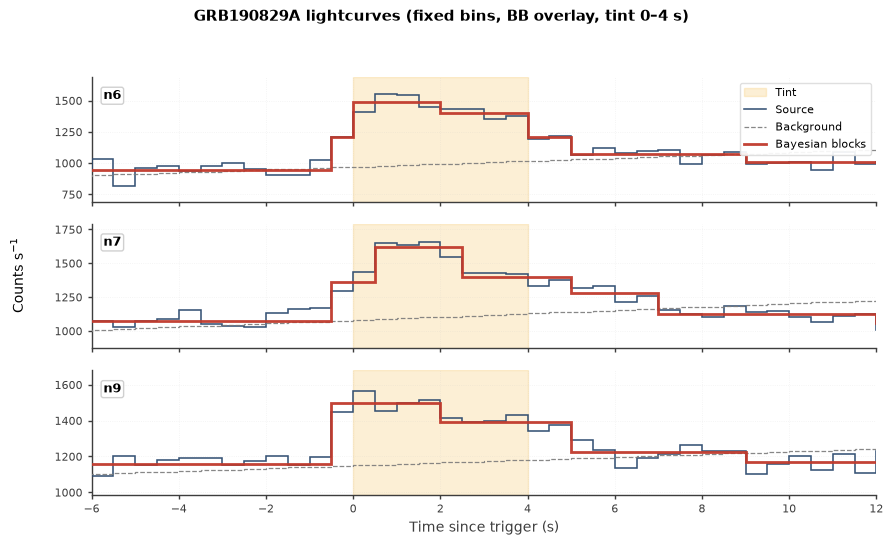

In [6]:
fig, axes = plot_lightcurves(
    ctx.name, data_base=ctx.data_base, lc_kind='fixed', plot_style='step',
    heapy_dir=active_heapy_tint_dir(ctx),
    t1=ctx.t1, t2=ctx.t2, overlay_bb=True, show_errors='none')
fig

### Sanity checks (LC window)

Confirm heapy wrote tint `.src` files and the LC extends past the GCN tint stop. Table C1 slice persistence is parked with tres.


In [7]:
heapy = active_heapy_tint_dir(ctx)
print(f'active heapy dir: {heapy}')
for det in ctx.sel_dets:
    src = os.path.join(heapy, f'tintegrated_{det}.src')
    print(f'  {det}: src={os.path.isfile(src)}')

nai = next((d for d in ctx.sel_dets if d[0] == 'n'), ctx.sel_dets[0])
bb_path = os.path.join(heapy, nai, 'bb_lc.json')
if os.path.isfile(bb_path):
    bb = json.load(open(bb_path))
    off = bb.get('time_offset')
    edges = bb['edges']
    rel0, rel1 = (edges[0] - off, edges[-1] - off) if off else (edges[0], edges[-1])
    print(f'LC window (rel): {rel0:.2f} → {rel1:.2f} s')
    assert rel1 >= ctx.t2 + 40, 'LC window still looks clipped'

print(f'tint=({ctx.t1}, {ctx.t2})  GCN=({GCN_REF["t1"]}, {GCN_REF["t2"]})')
print(f'Table C1 span kept for later tres: '
      f'{ctx.slice_boundaries[0]} → {ctx.slice_boundaries[-1]}')

# --- tres / slice persistence (parked) ---
# ctx.slice_mode = 'manual'
# from pipeline.slices import resolve_time_slices
# resolve_time_slices(ctx, persist=True)
# print('slice_mode=manual', ctx.time_slices)


active heapy dir: /workspace/data/GRB190829A/data/tintegrated/heapy/versions/9a900884
  n6: src=True
  n7: src=True
  n9: src=True
LC window (rel): -20.00 → 55.00 s
tint=(0.0, 4.0)  GCN=(0.0, 4.0)
Table C1 span kept for later tres: -0.81 → 5.07


## 3a — bayspec tint fit (NaI by default)


In [8]:
ctx = runner.run(ctx, stages=['fit_tint'])



=== GRB190829A stages=['fit_tint'] workers=1 model=cpl include_bgo=False ===

Fitting cpl (tint) | GRB190829A | fp=d3d9fe7d
  catalog dets=['n6', 'n7', 'n9']  fit dets=['n6', 'n7', 'n9']  include_bgo=False
  savepath=/workspace/data/GRB190829A/data/tintegrated/bayspec/cpl
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 1000
 dimensionality =    3
 *****************************************************
 ln(ev)=  -194.42136406455552      +/-  0.10605282604635004     
 Total Likelihood Evaluations:        46600
 Sampling finished. Exiting MultiNest
  analysing data from /workspace/data/GRB190829A/data/tintegrated/bayspec/cpl/1-.txt


✓ cpl -> /workspace/data/GRB190829A/data/tintegrated/bayspec/cpl


In [9]:
try:
    plot_infer_fit(
        ctx, model_name=MODEL, mode='tintegrated', style='CE',
        nlive=NLIVE, include_bgo=INCLUDE_BGO)
except FileNotFoundError as exc:
    print(exc)


 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 1000
 dimensionality =    3
 resuming from previous job
 *****************************************************
 ln(ev)=  -194.42136406455552      +/-  0.10605282604635004     
 Total Likelihood Evaluations:        46600
 Sampling finished. Exiting MultiNest
  analysing data from /workspace/data/GRB190829A/data/tintegrated/bayspec/cpl/1-.txt


## 4 — Extract bayspec params → HDF5

Writes **one** key: `tint_{model}_{GRB}` under `{GRB}_bayspec_data.h5`.

Prefer a cleaned HDF5 (checklist above) so old fingerprinted / 3ML-leaked keys are gone.


In [10]:
df_tint = extract_params(
    ctx, model_name=MODEL, mode='tintegrated', nlive=NLIVE,
    include_bgo=INCLUDE_BGO)

print('\n--- bayspec tint ---')
display(df_tint)
print('HDF5:', ctx.paths.bayspec_data)
view_hdf5(ctx.paths.bayspec_data)



Extracting cpl (tint) | GRB190829A | fit_dets=['n6', 'n7', 'n9']
  log Ep constrained: 1σ [1.948, 2.121]
  ✓ Saved HDF5 key 'tint_cpl_GRB190829A'
  ep_constrained=1

--- bayspec tint ---


,alpha,alpha_low,alpha_high,A,Ep_best,Ep_low,Ep_high,sigma_Ep,vFv_best,vFv_low,vFv_high,sigma_vFv,ep_constrained,log_Ep_hits_prior_low,log_Ep_hits_prior_high,log_Ep_1sigma_min,log_Ep_1sigma_max,log_Ep_prior_lo,log_Ep_prior_hi,alpha_ml,Ep_ml,A_ml,include_bgo
0,-0.921525,0.122042,0.135823,1.615485,106.02828,10.244395,12.762903,11.503649,1.348959e-07,6.075110e-09,6.326911e-09,6.201010e-09,1,0,0,1.947672,2.120948,0.0,4.0,-0.909974,103.81951,1.582944,0


HDF5: /workspace/data/GRB190829A/data/tresolved/bayspec/GRB190829A_bayspec_data.h5
Available keys: ['band', 'cpl', 'tint_band_GRB190829A', 'tint_cpl_GRB190829A']



## 5 — 3ML tint

Same TTE/poshist, tint window, and heapy LC pads as background.
HDF5 key: `tint_{model}_3ML_{GRB}` (own file under `data/tresolved/3ML/`).


In [11]:
df_3ml = None
threeml_result = None

if not RUN_3ML:
    print('RUN_3ML=False — skip')
else:
    ok, info = threeml_available()
    if not ok:
        raise RuntimeError(f'threeML unavailable: {info}')
    print('3ML bkg:', _bkg_intervals(ctx))
    threeml_result = run_3ml(
        ctx, model_name=MODEL, mode='tintegrated', nlive=NLIVE,
        include_bgo=INCLUDE_BGO, force=FORCE)
    df_3ml = extract_params_3ml(
        ctx, model_name=MODEL, mode='tintegrated', nlive=NLIVE,
        include_bgo=INCLUDE_BGO, save_root=threeml_result.get('root'),
        fp=threeml_result.get('fp'))
    print('\n--- 3ML tint ---')
    display(df_3ml)
    h5_3ml = os.path.join(ctx.paths.tresolved_path, '3ML', f'{ctx.name}_3ML_data.h5')
    print('root:', threeml_result.get('root'))
    print('HDF5:', h5_3ml)
    view_hdf5(h5_3ml)


3ML bkg: ['-20.000--0.810', '5.070-55.070']
  one_fits_all detectors: ['n6', 'n7', 'n9']

=== 3ML GRB190829A mode=tintegrated model=cpl dets=['n6', 'n7', 'n9'] nlive=1000 bin=custom fp=207c4ec7 ===
  savepath=/workspace/data/GRB190829A/data/tintegrated/3ML/cpl
  3ML bkg (heapy LC pads − burst): ['-20.000--0.810', '5.070-55.070']
  [3ML] n6 DRM @ t=2.00s  src=0–4


Finding best polynomial Order:   0%|          | 0/4 [00:00<?, ?it/s]

16:27:36 INFO      Auto-determined polynomial order: 3                                            ]8;id=15354517;file:///usr/local/lib/python3.12/site-packages/threeML/utils/time_series/event_list.py\event_list.py]8;;\:]8;id=15354518;file:///usr/local/lib/python3.12/site-packages/threeML/utils/time_series/event_list.py#505\505]8;;\

Fitting GBM_NAI_06 background:   0%|          | 0/128 [00:00<?, ?it/s]

16:27:39 INFO      None 3-order polynomial fit with the mle method                               ]8;id=15354525;file:///usr/local/lib/python3.12/site-packages/threeML/utils/time_series/time_series.py\time_series.py]8;;\:]8;id=15354526;file:///usr/local/lib/python3.12/site-packages/threeML/utils/time_series/time_series.py#426\426]8;;\

...

Values of statistical measures:

,statistical measures
AIC,3529.777191
BIC,3541.410401
DIC,3487.378473
PDIC,-28.363336
log(Z),-766.204298


  Saved 3ML posterior: /workspace/data/GRB190829A/data/tintegrated/3ML/cpl/GRB190829A-post_equal_weights.dat
  log Ep constrained: 1σ [1.975, 2.179]
  ✓ 3ML params → /workspace/data/GRB190829A/data/tresolved/3ML/GRB190829A_3ML_data.h5  key=tint_cpl_3ML_GRB190829A
  ep_constrained=[1]
  log Ep constrained: 1σ [1.975, 2.179]
  ✓ 3ML params → /workspace/data/GRB190829A/data/tresolved/3ML/GRB190829A_3ML_data.h5  key=tint_cpl_3ML_GRB190829A
  ep_constrained=[1]

--- 3ML tint ---


,alpha,alpha_low,alpha_high,A,Ep_best,Ep_low,Ep_high,sigma_Ep,vFv_best,vFv_low,vFv_high,sigma_vFv,ep_constrained,log_Ep_hits_prior_low,log_Ep_hits_prior_high,log_Ep_1sigma_min,log_Ep_1sigma_max,log_Ep_prior_lo,log_Ep_prior_hi,alpha_ml,Ep_ml,A_ml,model,backend,t_start,t_stop,include_bgo
0,-0.643057,0.177465,0.196886,0.455225,114.651724,12.161593,17.547558,14.854576,1.179281e-07,7.038480e-09,7.052563e-09,7.045522e-09,1,0,0,1.975345,2.178914,0.0,4.0,-0.630727,113.566297,0.443311,cpl,3ML,0.0,4.0,0


root: /workspace/data/GRB190829A/data/tintegrated/3ML/cpl
HDF5: /workspace/data/GRB190829A/data/tresolved/3ML/GRB190829A_3ML_data.h5
Available keys: ['tint_cpl_3ML_GRB190829A']



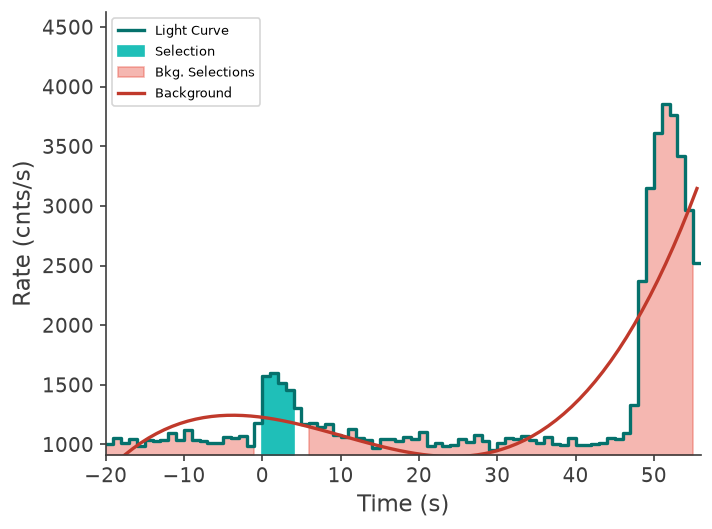

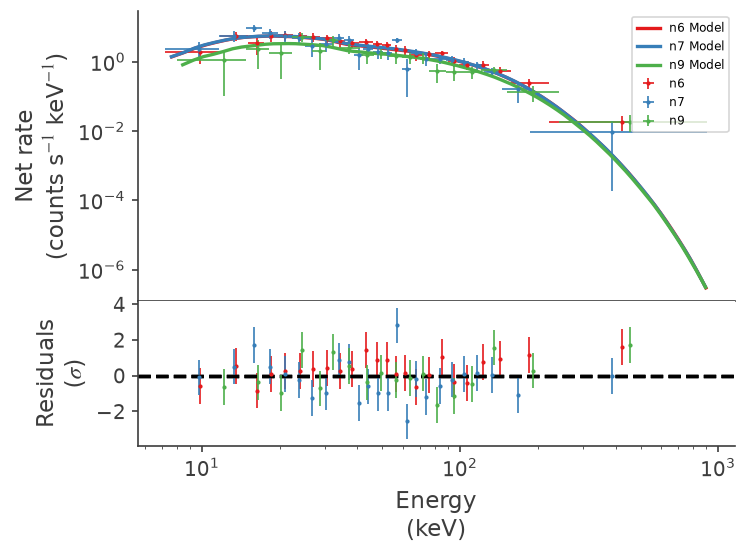

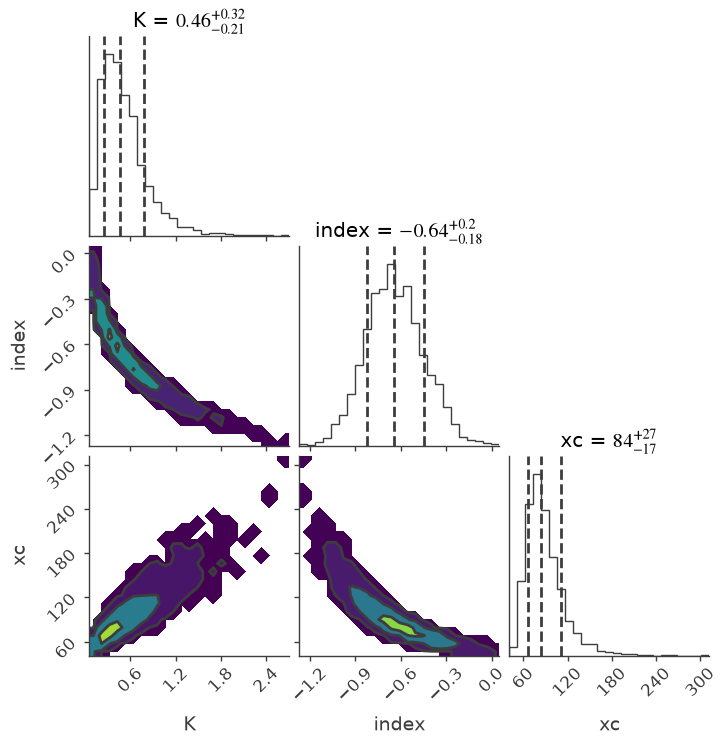

In [12]:
if threeml_result and threeml_result.get('root'):
    root = threeml_result['root']
    for name in ('lc.png', 'ctsspec.png', 'corner.png'):
        path = os.path.join(root, name)
        if os.path.isfile(path):
            display(Image(filename=path))
else:
    print('No 3ML plots yet.')


## 6 — Comparison table

**One table:** GCN circular · bayspec · 3ML for the tint CPL (NaI by default).

α / Ep are **equal-weight 16/50/84**. Δα and ΔEp are fit median minus GCN. Loads from in-memory `df_tint` / `df_3ml` if you just ran sections 4–5; otherwise reads the canonical HDF5 keys.


In [13]:
def _pm(v, lo, hi, digits=3):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return '—'
    if lo is None or hi is None or not (np.isfinite(lo) and np.isfinite(hi)):
        return f'{float(v):.{digits}g}'
    return f'{float(v):.{digits}g} −{float(lo):.{digits}g}/+{float(hi):.{digits}g}'


def _delta(val, ref, digits=3):
    if val is None or ref is None:
        return '—'
    try:
        v, r = float(val), float(ref)
    except (TypeError, ValueError):
        return '—'
    if not (np.isfinite(v) and np.isfinite(r)):
        return '—'
    return f'{v - r:+.{digits}g}'


def _row_from_series(label, row, gcn):
    if row is None:
        return {
            'source': label, 'α': '—', 'Ep (keV)': '—',
            'Δα': '—', 'ΔEp (keV)': '—', 'ep_constrained': '—',
        }
    r = row.to_dict() if hasattr(row, 'to_dict') else dict(row)
    alpha = r.get('alpha')
    ep = r.get('Ep_best', r.get('Ep'))
    constrained = r.get('ep_constrained', None)
    return {
        'source': label,
        'α': _pm(alpha, r.get('alpha_low'), r.get('alpha_high'), 3),
        'Ep (keV)': _pm(ep, r.get('Ep_low'), r.get('Ep_high'), 4),
        'Δα': _delta(alpha, gcn.get('alpha'), 3),
        'ΔEp (keV)': _delta(ep, gcn.get('Ep'), 4),
        'ep_constrained': (
            '—' if constrained is None else ('yes' if int(constrained) else 'no')),
    }


def _load_tint_row(h5, key):
    if not os.path.isfile(h5):
        return None
    try:
        import h5py
        with h5py.File(h5, 'r') as f:
            if key not in f:
                return None
        return pd.read_hdf(h5, key=key).iloc[0]
    except Exception as exc:
        print(f'  skip {h5} [{key}]: {exc}')
        return None


bay_df = globals().get('df_tint', None)
ml_df = globals().get('df_3ml', None)
bay = None if bay_df is None or len(bay_df) == 0 else bay_df.iloc[0]
ml = None if ml_df is None or len(ml_df) == 0 else ml_df.iloc[0]

h5_bay = ctx.paths.bayspec_data
h5_3ml = os.path.join(ctx.paths.tresolved_path, '3ML', f'{ctx.name}_3ML_data.h5')
key_bay = f'tint_{MODEL}_{ctx.name}'
key_3ml = f'tint_{MODEL}_3ML_{ctx.name}'
if bay is None:
    bay = _load_tint_row(h5_bay, key_bay)
if ml is None:
    ml = _load_tint_row(h5_3ml, key_3ml)

comparison = pd.DataFrame([
    {
        'source': GCN_REF['source'],
        'α': _pm(GCN_REF['alpha'], GCN_REF['alpha_err'], GCN_REF['alpha_err'], 3),
        'Ep (keV)': _pm(GCN_REF['Ep'], GCN_REF['Ep_err'], GCN_REF['Ep_err'], 4),
        'Δα': '0',
        'ΔEp (keV)': '0',
        'ep_constrained': '—',
    },
    _row_from_series(f'bayspec {MODEL}', bay, GCN_REF),
    _row_from_series(f'3ML {MODEL}', ml, GCN_REF),
])

print(f'{ctx.name} tint comparison  (t1,t2)=({ctx.t1}, {ctx.t2})  '
      f'NaI-only={not INCLUDE_BGO}  nlive={NLIVE}')
print(f'GCN {GCN_REF["source"]}: α={GCN_REF["alpha"]}±{GCN_REF["alpha_err"]}  '
      f'Ep={GCN_REF["Ep"]}±{GCN_REF["Ep_err"]} keV  '
      f'interval=({GCN_REF["t1"]}, {GCN_REF["t2"]})')
print(f'bayspec HDF5: {h5_bay}  key={key_bay}  loaded={bay is not None}')
print(f'3ML HDF5:     {h5_3ml}  key={key_3ml}  loaded={ml is not None}')
print('3ML bkg:', _bkg_intervals(ctx))
display(comparison)

out_csv = os.path.join(ctx.paths.tintegrated_path, f'{ctx.name}_tint_{MODEL}_comparison.csv')
os.makedirs(ctx.paths.tintegrated_path, exist_ok=True)
comparison.to_csv(out_csv, index=False)
settings_path = os.path.join(ctx.paths.tintegrated_path, f'{ctx.name}_tint_{MODEL}_settings.json')
with open(settings_path, 'w') as f:
    json.dump(settings, f, indent=2)
print('wrote', out_csv)
print('wrote', settings_path)


GRB190829A tint comparison  (t1,t2)=(0.0, 4.0)  NaI-only=True  nlive=1000
GCN GCN 25575: α=-1.41±0.08  Ep=130.0±20.0 keV  interval=(0.0, 4.0)
bayspec HDF5: /workspace/data/GRB190829A/data/tresolved/bayspec/GRB190829A_bayspec_data.h5  key=tint_cpl_GRB190829A  loaded=True
3ML HDF5:     /workspace/data/GRB190829A/data/tresolved/3ML/GRB190829A_3ML_data.h5  key=tint_cpl_3ML_GRB190829A  loaded=True
3ML bkg: ['-20.000--0.810', '5.070-55.070']


,source,α,Ep (keV),Δα,ΔEp (keV),ep_constrained
0,GCN 25575,-1.41 −0.08/+0.08,130 −20/+20,0,0,—
1,bayspec cpl,-0.922 −0.122/+0.136,106 −10.24/+12.76,+0.488,-23.97,yes
2,3ML cpl,-0.643 −0.177/+0.197,114.7 −12.16/+17.55,+0.767,-15.35,yes


wrote /workspace/data/GRB190829A/data/tintegrated/GRB190829A_tint_cpl_comparison.csv
wrote /workspace/data/GRB190829A/data/tintegrated/GRB190829A_tint_cpl_settings.json


## 7 — On-disk results


In [14]:
list_grb_results(ctx.name)
show_directory_tree(ctx.paths.base, max_depth=3)
for label, rel in (
    ('bayspec HDF5', f'data/tresolved/bayspec/{ctx.name}_bayspec_data.h5'),
    ('3ML HDF5', f'data/tresolved/3ML/{ctx.name}_3ML_data.h5'),
    ('bayspec tint', f'data/tintegrated/bayspec/{MODEL}'),
    ('3ML tint', f'data/tintegrated/3ML/{MODEL}'),
):
    p = os.path.join(ctx.paths.base, rel)
    print(f'{label}: exists={os.path.exists(p)}  {p}')



=== GRB190829A results ===
Available keys: ['band', 'cpl', 'tint_band_GRB190829A', 'tint_cpl_GRB190829A']


tint heapy: /workspace/data/GRB190829A/data/tintegrated/heapy
  versions: ['85462c17', '9a900884']
  meta: {
  "slices": {
    "slice_mode": "manual",
    "time_slices": [
      [
        -0.81,
        0.33
      ],
      [
        0.33,
        0.81
      ],
      [
        0.81,
        1.26
      ],
      [
        1.26,
        1.8
      ],
      [
        1.8,
        2.43
      ],
      [
        2.43,
        5.07
      ]
    ],
    "slice_boundaries": [
      -0.81,
      0.33,
      0.81,
      1.26,
      1.8,
      2.43,
      5.07
    ],
    "bb_boundaries": null,
    "bb_slices": null,
    "bb_det": null,
    "t1": 0.0,
    "t2": 4.0
  },
  "canonical_extraction": "9a900884",
  "runs": {
    "9a900884": {
      "t1": 0.0,
      "t2": 4.0,
      "sel_dets": [
        "n6",
        "n7",
        "n9"
      ],
      "slice_mode": "manual",
      "time_slices": [
     

## Optional — time-resolved (commented / parked)

Do **not** run this for the tint git snapshot. Heapy+bayspec tres is opt-in. 3ML tres bins follow
[TimeSeriesBuilder.create_time_bins](https://threeml.readthedocs.io/en/stable/notebooks/Building_Plugins_from_TimeSeries.html).
`bin_method='custom'` keeps Table C1 / `ctx.time_slices`.


In [15]:
# --- heapy + bayspec tres (unchanged) ---
# ctx = runner.run(ctx, stages=['spectra_tres', 'fit_tres'])
# df_tres = extract_params(
#     ctx, model_name=MODEL, mode='tresolved', nlive=NLIVE,
#     include_bgo=INCLUDE_BGO)
# display(df_tres)
# from plotting.params import plot_tres_params
# fig, _ = plot_tres_params(df_tres, title=f'{ctx.name} bayspec {MODEL} tres')
# fig

# --- 3ML tres: preview bins then fit ---
# BIN_METHOD = 'bayesblocks'   # custom | constant | significance | bayesblocks
# BIN_KW = dict(p0=0.01, min_width=0.1, dt=2.0, sigma=25.0)
# from pipeline.detectors import fit_detectors
# from plotting.params import plot_tres_params
# dets = fit_detectors(ctx.sel_dets, include_bgo=INCLUDE_BGO) or list(ctx.sel_dets)
# slices, bin_info = resolve_3ml_bins(
#     ctx, dets, bin_method=BIN_METHOD, bin_kwargs=BIN_KW,
#     persist_dir=os.path.join(ctx.paths.tresolved_path, '3ML'))
# print('ref_det', bin_info.get('ref_det'), 'n_raw', len(bin_info['raw_slices']),
#       'n_merged', len(slices))
# display(pd.DataFrame(
#     [{'slice': i, 't_start': a, 't_stop': b, 'dt': b - a}
#      for i, (a, b) in enumerate(slices, 1)]))
# tres_3ml = run_3ml(
#     ctx, model_name=MODEL, mode='tresolved', nlive=NLIVE,
#     include_bgo=INCLUDE_BGO, force=FORCE,
#     bin_method=BIN_METHOD, bin_kwargs=BIN_KW)
# df_3ml_tres = pd.DataFrame(tres_3ml['params']) if tres_3ml.get('params') else None
# display(df_3ml_tres)
# fig, _ = plot_tres_params(df_3ml_tres, title=f'{ctx.name} 3ML {MODEL} tres')
# fig
# # also on disk: {tres_3ml["root"]}/tres_params.png
